# Анализ перевозок грузов по видам транспорта в России (2000–2024)

В ноутбуке:

- загрузка данных по видам транспорта;
- базовый обзор датасета;
- построение нескольких графиков (динамика, сравнение, структура);
- краткие текстовые выводы по каждому графику.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Настройки отображения графиков в Jupyter
%matplotlib inline

# Ввод данных вручную (как в исходном Excel-файле)
data = {
    'Год': [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'железнодорожный': [1046.8, 1057.5, 1083.7, 1160.9, 1221.2, 1273.3, 1311.6, 1344.6, 1304.4, 1108.8, 1312.0, 1381.7, 1421.1, 1381.2, 1375.4, 1329.0, 1325.2, 1384.3, 1410.9, 1398.6, 1358.5, 1403.9, 1351.3, 1365.2, 1306.1],
    'автомобильный': [5878.4, 6125.3, 6347.7, 6468.1, 6567.8, 6684.6, 6753.3, 6861.4, 6893.1, 5240.5, 5236.4, 5663.1, 5841.6, 5635.3, 5416.7, 5356.7, 5396.8, 5403.9, 5544.4, 5735.3, 5404.7, 5581.7, 6210.6, 6491.2, 6775.9],
    'газопроводный': [511.2, 508.8, 513.8, 544.5, 555.1, 565.8, 581.1, 571.6, 578.6, 480.0, 536.6, 555.1, 541.1, 537.5, 512.0, 493.0, 509.4, 548.8, 566.4, 550.9, 511.6, 574.6, 484.3, np.nan, np.nan],
    'нефтепроводный': [294.6, 319.7, 359.8, 404.3, 441.5, 454.1, 460.8, 461.8, 456.4, 474.4, 491.7, 543.8, 523.4, 524.6, 532.1, 543.3, 543.4, 553.4, 561.1, 567.7, 509.5, 523.9, 544.4, np.nan, np.nan],
    'нефтепродуктопроводный': [23.1, 24.9, 25.7, 27.6, 27.6, 28.2, 28.4, 28.7, 31.6, 30.6, 33.2, 32.0, 32.0, 33.1, 34.0, 34.7, 35.2, 36.1, 41.8, 40.5, 40.4, 42.9, 44.1, np.nan, np.nan],
    'морской': [35.4, 33.8, 37.3, 35.7, 29.1, 26.0, 25.4, 28.1, 35.2, 37.4, 37.0, 34.0, 18.3, 16.7, 15.8, 18.8, 24.6, 26.4, 23.2, 23.2, 24.7, 23.4, 27.6, 33.2, 31.9],
    'внутренний_водный': [116.8, 129.5, 118.7, 125.8, 135.0, 134.2, 139.2, 153.4, 150.8, 96.9, 102.4, 126.2, 140.5, 134.9, 119.1, 121.4, 118.0, 118.5, 116.2, 108.2, 109.0, 110.5, 116.4, 109.3, 105.4],
    'воздушный': [0.8, 0.9, 0.9, 0.8, 0.9, 0.8, 0.9, 1.0, 1.0, 0.9, 1.1, 1.2, 1.2, 1.2, 1.3, 1.0, 1.1, 1.3, 1.3, 1.3, 1.3, 1.6, 0.7, 0.6, 0.6]
}

df = pd.DataFrame(data)
df.head()


,Год,железнодорожный,автомобильный,газопроводный,нефтепроводный,нефтепродуктопроводный,морской,внутренний_водный,воздушный
0,2000,1046.8,5878.4,511.2,294.6,23.1,35.4,116.8,0.8
1,2001,1057.5,6125.3,508.8,319.7,24.9,33.8,129.5,0.9
2,2002,1083.7,6347.7,513.8,359.8,25.7,37.3,118.7,0.9
3,2003,1160.9,6468.1,544.5,404.3,27.6,35.7,125.8,0.8
4,2004,1221.2,6567.8,555.1,441.5,27.6,29.1,135.0,0.9


In [7]:
# Общая информация о датасете
print(df.info())
print("Описательная статистика:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Год                     25 non-null     int64  
 1   железнодорожный         25 non-null     float64
 2   автомобильный           25 non-null     float64
 3   газопроводный           23 non-null     float64
 4   нефтепроводный          23 non-null     float64
 5   нефтепродуктопроводный  23 non-null     float64
 6   морской                 25 non-null     float64
 7   внутренний_водный       25 non-null     float64
 8   воздушный               25 non-null     float64
dtypes: float64(8), int64(1)
memory usage: 1.9 KB
None
Описательная статистика:


,Год,железнодорожный,автомобильный,газопроводный,нефтепроводный,нефтепродуктопроводный,морской,внутренний_водный,воздушный
count,25.000000,25.000000,25.000000,23.000000,23.000000,23.000000,25.000000,25.000000,25.000000
mean,2012.000000,1296.688000,5980.580000,536.165217,482.160870,32.886957,28.088000,122.252000,1.028000
std,7.359801,115.452553,572.227786,30.909349,76.575404,5.936812,6.748723,14.587584,0.250865
min,2000.000000,1046.800000,5236.400000,480.000000,294.600000,23.100000,15.800000,96.900000,0.600000
25%,2006.000000,1273.300000,5416.700000,511.400000,455.250000,28.300000,23.400000,110.500000,0.900000
50%,2012.000000,1329.000000,5841.600000,541.100000,509.500000,32.000000,27.600000,118.700000,1.000000
75%,2018.000000,1381.200000,6491.200000,560.450000,543.350000,35.650000,34.000000,134.200000,1.200000
max,2024.000000,1421.100000,6893.100000,581.100000,567.700000,44.100000,37.400000,153.400000,1.600000


## График 1. Динамика всех видов транспорта

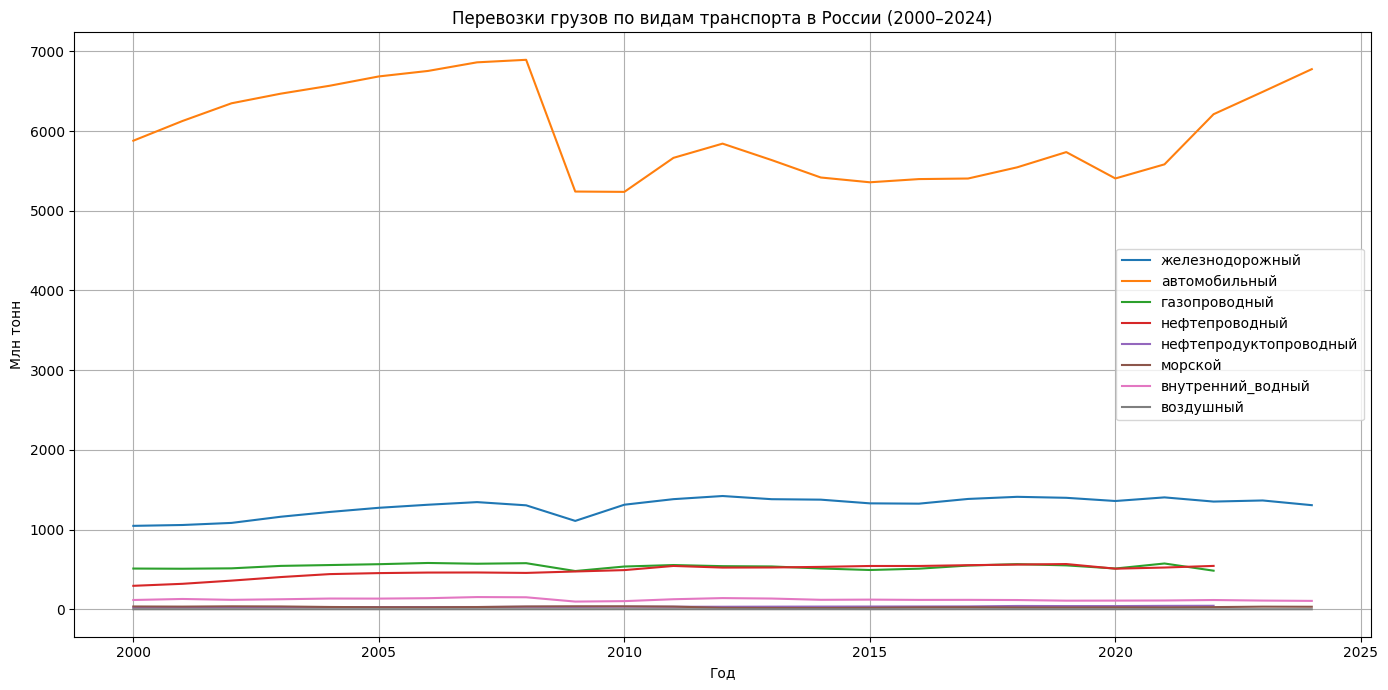

In [8]:
# График 1. Динамика всех видов транспорта
plt.figure(figsize=(14, 7))
for col in df.columns:
    if col != 'Год':
        plt.plot(df['Год'], df[col], label=col)

plt.title('Перевозки грузов по видам транспорта в России (2000–2024)')
plt.xlabel('Год')
plt.ylabel('Млн тонн')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Основные наблюдения по графику 1:

- Автомобильный транспорт доминирует по объёмам перевозок во все годы.
- Железнодорожный транспорт стабильно занимает второе место.
- Трубопроводные виды (газо-, нефте-, нефтепродуктопроводный) имеют сопоставимые уровни и более плавную динамику.
- В 2009 году заметен спад по ряду видов транспорта (мировой кризис).


## График 2. Сравнение ключевых лет

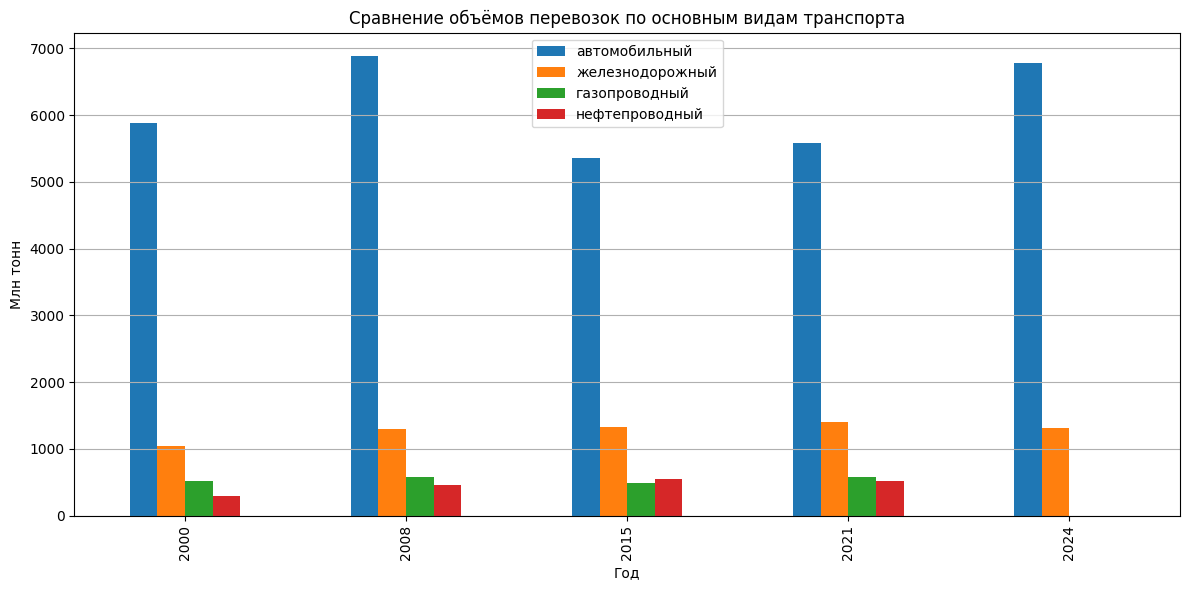

In [9]:
# График 2. Сравнение ключевых лет для основных видов транспорта
key_years = [2000, 2008, 2015, 2021, 2024]
main_cols = ['автомобильный', 'железнодорожный', 'газопроводный', 'нефтепроводный']

subset = df[df['Год'].isin(key_years)].set_index('Год')
subset[main_cols].plot(kind='bar', figsize=(12, 6))
plt.title('Сравнение объёмов перевозок по основным видам транспорта')
plt.xlabel('Год')
plt.ylabel('Млн тонн')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Выводы по графику 2:

- Автомобильный транспорт значительно превосходит все остальные виды во все выбранные годы.
- Железнодорожный транспорт растёт медленнее и демонстрирует более стабильную динамику.
- Газопроводный и нефтепроводный транспорт имеют меньшие, но сопоставимые объёмы.


## График 3. Структура перевозок в 2021 году

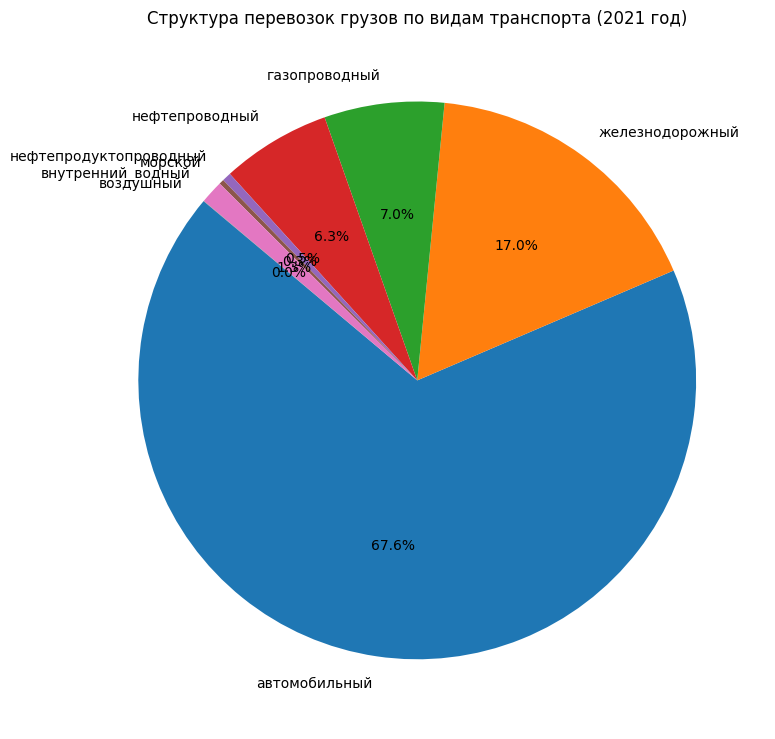

In [10]:
# График 3. Структура перевозок по видам транспорта в 2021 году
row_2021 = df[df['Год'] == 2021].iloc[0]
labels = [
    'автомобильный', 'железнодорожный', 'газопроводный', 'нефтепроводный',
    'нефтепродуктопроводный', 'морской', 'внутренний_водный', 'воздушный'
]
values = [row_2021[l] for l in labels]

plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Структура перевозок грузов по видам транспорта (2021 год)')
plt.tight_layout()
plt.show()


Выводы по структуре 2021 года:

- Автомобильный транспорт формирует основную долю перевозок.
- Железнодорожный транспорт занимает заметную, но гораздо меньшую долю.
- Вклад трубопроводных видов транспорта в сумме также значителен.
- Морской, внутренний водный и воздушный виды играют вспомогательную роль по объёмам.


## График 4. Сравнение автомобильного и железнодорожного транспорта

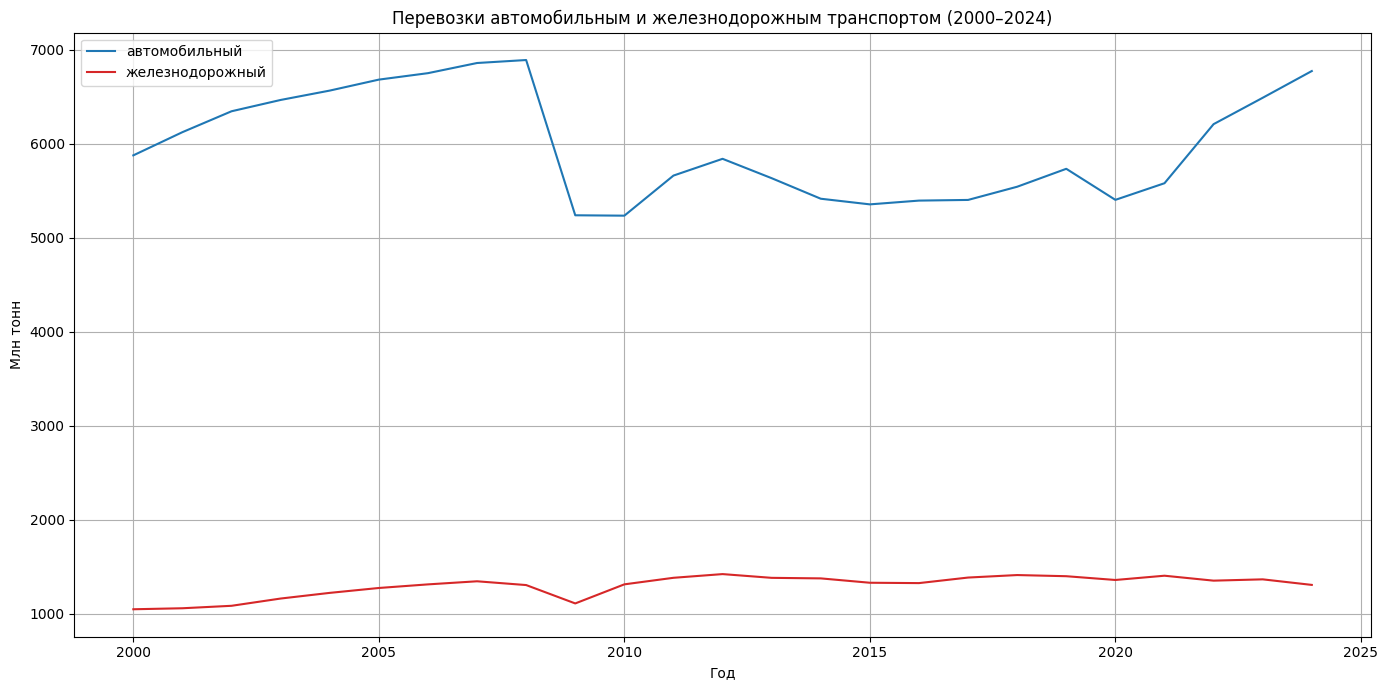

In [11]:
# График 4. Сравнение автомобильного и железнодорожного транспорта
plt.figure(figsize=(14, 7))
plt.plot(df['Год'], df['автомобильный'], label='автомобильный', color='tab:blue')
plt.plot(df['Год'], df['железнодорожный'], label='железнодорожный', color='tab:red')

plt.title('Перевозки автомобильным и железнодорожным транспортом (2000–2024)')
plt.xlabel('Год')
plt.ylabel('Млн тонн')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Выводы по графику 4:

- Автомобильный транспорт растёт быстрее и имеет больший разброс значений.
- Железнодорожный транспорт более стабилен, но также чувствителен к кризисным периодам.
- В долгосрочной перспективе сохраняется разрыв между автомобильным и железнодорожным транспортом.


## График 5. Трубопроводный транспорт

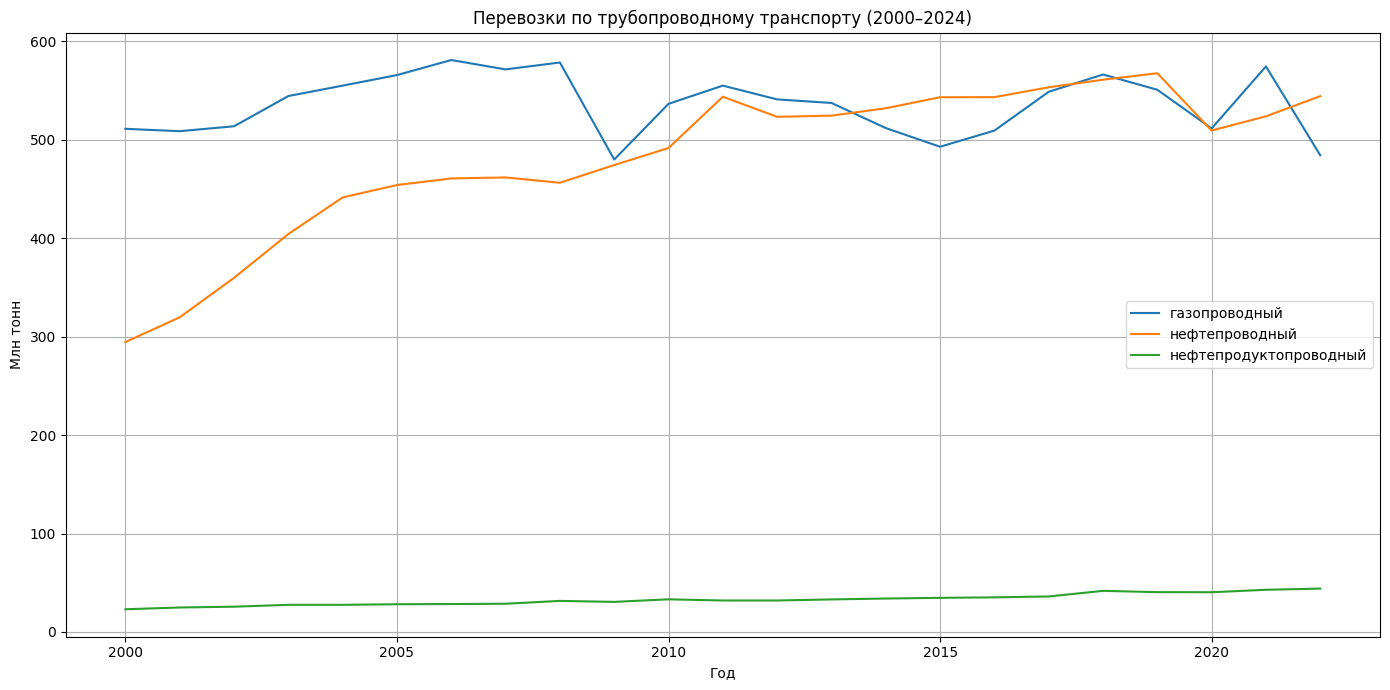

In [12]:
# График 5. Трубопроводный транспорт
pipe_cols = ['газопроводный', 'нефтепроводный', 'нефтепродуктопроводный']

plt.figure(figsize=(14, 7))
for col in pipe_cols:
    plt.plot(df['Год'], df[col], label=col)

plt.title('Перевозки по трубопроводному транспорту (2000–2024)')
plt.xlabel('Год')
plt.ylabel('Млн тонн')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Выводы по трубопроводному транспорту:

- Газопроводный транспорт имеет наибольшие объёмы среди трубопроводных видов.
- Нефтепроводный транспорт демонстрирует плавный рост до 2010-х с последующей стабилизацией.
- Нефтепродуктопроводный транспорт имеет наименьшие объёмы, но также тенденцию к росту.
